<a href="https://colab.research.google.com/github/fernandezsophia520/QLC_140G_SP26/blob/main/Coding_Exercise4_qlc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#intall the packages needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install netcdf4
import netCDF4
import urllib.request as urllib2

below we are going to plot data from an oceangliber.search the web.

-what is an ocean glider?
-how does it move?

In [6]:
import csv
import matplotlib.pyplot as plt
import matplotlib.dates as md
import datetime
from io import StringIO
#retreive data from the glider server
response = urllib2.urlopen ('http://glider.ceotr.ca/data/live/otn200_sci_water_sal_live.csv')
data = response.read().decode('utf-8') #decode the response to a string
data = StringIO(data)

# read file
r = csv.DictReader (data)
#print top 10 lines of r dataframe

# Convert the DictReader object to a list to easily access rows
r_list = list(r)

# Print the first 10 lines
for i, row in enumerate(r_list):
    if i >= 10:
        break
    print(row)

{'unixtime': '1370530681.4415', 'lat': ' 44.533653577385195', 'lon': ' -63.393453793673935', 'depth': ' 35.2', 'sci_water_sal': ' 31.852892253513247'}
{'unixtime': '1370530742.2388', 'lat': ' 44.53351946378085', 'lon': ' -63.39334395323845', 'depth': ' 26.06', 'sci_water_sal': ' 31.717310598606883'}
{'unixtime': '1370530802.37628', 'lat': ' 44.53338680568273', 'lon': ' -63.39323530487769', 'depth': ' 17.29', 'sci_water_sal': ' 31.462472169658824'}
{'unixtime': '1370530863.38712', 'lat': ' 44.5332522210279', 'lon': ' -63.39312507864697', 'depth': ' 8.83', 'sci_water_sal': ' 31.127901282228475'}
{'unixtime': '1370530924.34824', 'lat': ' 44.53311774605122', 'lon': ' -63.39301494224378', 'depth': ' 2.14', 'sci_water_sal': ' 31.03919875193208'}
{'unixtime': '1370530984.70169', 'lat': ' 44.532984611541806', 'lon': ' -63.392905903697226', 'depth': ' 0.08', 'sci_water_sal': ' 31.063125057254904'}
{'unixtime': '1370531045.39243', 'lat': ' 44.53306864305745', 'lon': ' -63.39281438058511', 'depth

In [7]:
df = pd.DataFrame(r_list)
display(df.head())

,unixtime,lat,lon,depth,sci_water_sal
0,1370530681.4415,44.533653577385195,-63.393453793673935,35.2,31.852892253513247
1,1370530742.2388,44.53351946378085,-63.39334395323845,26.06,31.717310598606883
2,1370530802.37628,44.53338680568273,-63.39323530487769,17.29,31.462472169658824
3,1370530863.38712,44.5332522210279,-63.39312507864697,8.83,31.127901282228475
4,1370530924.34824,44.53311774605122,-63.39301494224378,2.14,31.03919875193208


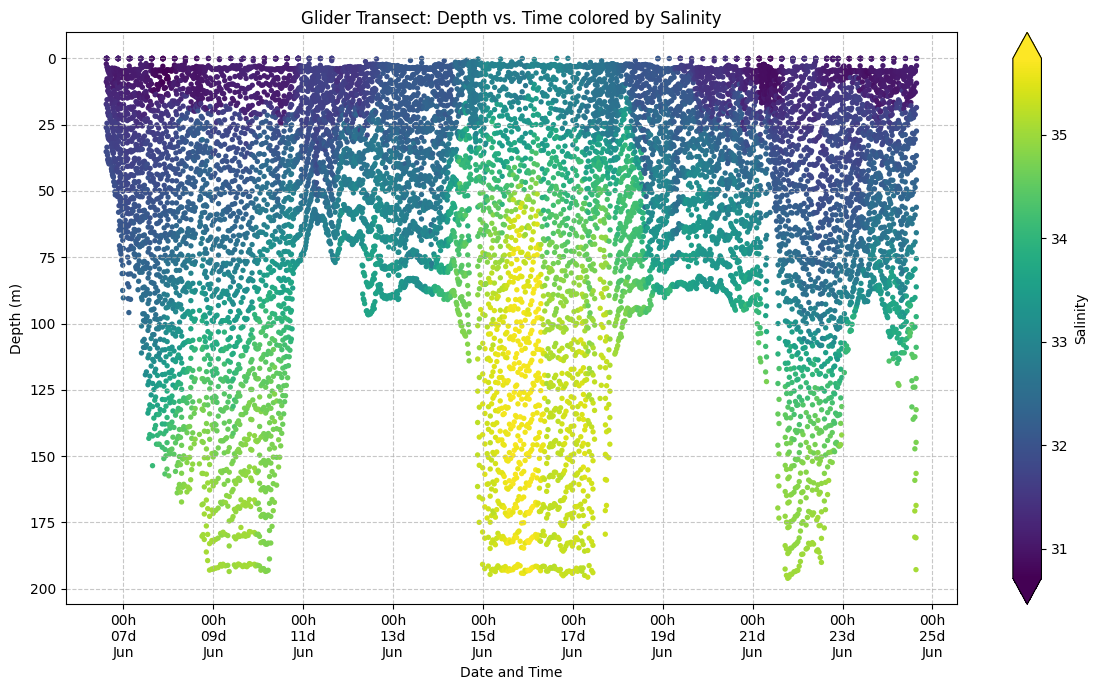

In [16]:
# Convert relevant columns to numeric types
df['unixtime'] = pd.to_numeric(df['unixtime'])
df['lat'] = pd.to_numeric(df['lat'])
df['lon'] = pd.to_numeric(df['lon'])
df['depth'] = pd.to_numeric(df['depth'])
df['sci_water_sal'] = pd.to_numeric(df['sci_water_sal'])

# Convert unixtime to datetime objects for plotting
df['DATE'] = pd.to_datetime(df['unixtime'], unit='s')

# Make plot
fig, ax1 = plt.subplots(1, figsize=(12, 7))
plt.scatter(df['DATE'], df['depth'], s=15, c=df['sci_water_sal'], marker='o', edgecolor='none', cmap='viridis')

# Invert y-axis for depth (0 at top, increasing downwards)
ax1.set_ylim(ax1.get_ylim()[::-1])

cbar = plt.colorbar(orientation='vertical', extend='both') # Changed to vertical for better readability
cbar.ax.set_ylabel('Salinity')

# Format x-axis for dates
xfmt = md.DateFormatter('%Hh\n%dd\n%b')
ax1.xaxis.set_major_formatter(xfmt)

plt.title('Glider Transect: Depth vs. Time colored by Salinity')
plt.xlabel('Date and Time')
plt.ylabel('Depth (m)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

what is this plot showing? can you gain any information about the water column at this location?

- this plot is showing salinity at different depths in the ocean over the month of june. you can tell that this water columns has alot more salinity as you get deeper.this shows upwelling/downwelling and a shift in the water descriptions.


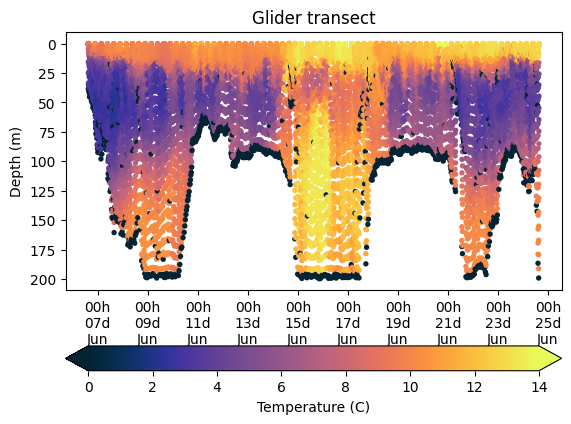

In [23]:
import csv
import matplotlib.pyplot as plt
import matplotlib.dates as md
import datetime
from io import StringIO
# Retreive data from the "glider" server
response = urllib2.urlopen('http://glider.ceotr.ca/data/live/otn200_sci_water_temp_live.csv')
data = response.read().decode('utf-8')  # Decode the response to a string
data = StringIO(data)

# Read file
r = csv.DictReader(data)

# Initialize empty variables
date, lat, lon, depth, temp = [],[],[],[],[]

# Loop to parse data into our variables
for row in r:
    date.append(float(row['unixtime']))
    lat.append(float(row['lat']))
    lon.append(float(row['lon']))
    depth.append(float(row['depth']))
    temp.append(float(row['sci_water_temp']))

# Change unix-time into a date object (for easy plotting)
DATE = []
for row in date:
    DATE.append(datetime.datetime.fromtimestamp(row))

# Make plot
fig, ax1 = plt.subplots(1)
plt.scatter(DATE,depth,s=15,c=temp,marker='o', edgecolor='none', cmap=cmocean.cm.thermal )
#plt.ylim((-0.5,max(depth)+5))
ax1.set_ylim(ax1.get_ylim()[::-1])
cbar = plt.colorbar(orientation='horizontal', extend='both')
xfmt = md.DateFormatter('%Hh\n%dd\n%b')
ax1.xaxis.set_major_formatter(xfmt)
cbar.ax.set_xlabel('Temperature (C)')
plt.title('Glider transect')
plt.ylabel('Depth (m)')
plt.show()

In [20]:
#install cmocean package
!pip install cmocean
#import cmocean package
import cmocean

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 8.0 MB/s eta 0:00:00
